# Phase 3: Model Performance and Degradation Analysis

This notebook analyzes the regression results obtained from the Phase 3 modeling pipeline.
The goal is to evaluate model performance, analyze degradation trends, and interpret the predicted Remaining Useful Life (RUL) across batteries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#read the data from the CSV file
Regression_DF = pd.read_csv("C:\Projects\Battery Engineering\Summary Files\Regression_Results (Phase_3).csv")

EOL_DF = pd.read_csv("C:\Projects\Battery Engineering\Summary Files\Battery_Cycle_Estimation .csv")

#Filtering the data to include only 'No Spike' and 'Pre Spike' segments 

Filtered_Regression_DF = Regression_DF[(Regression_DF['Segment'] == 'No Spike') | (Regression_DF['Segment'] == 'Pre Spike')]

In [2]:
#Checking Data Heads
print(Regression_DF.head())
print(EOL_DF.head())


  Battery     Segment                  Model     Slope   Intercept  Train_MAE  \
0   B0005   Pre Spike  Polynomial Regression -0.210541   98.873010   0.641272   
1   B0005  Post Spike      Linear Regression -0.200789  101.299281   0.608409   
2   B0006   Pre Spike      Linear Regression -0.333512  102.094805   1.378168   
3   B0006  Post Spike      Linear Regression -0.201719   92.955109   0.709531   
4   B0007   Pre Spike  Polynomial Regression -0.204071   99.438530   0.450669   

   Test_MAE  Train_MSE  Test_MSE  
0  0.850176   0.702971  1.076562  
1  1.906253   0.823774  4.242475  
2  1.008852   3.136100  1.371948  
3  0.633669   1.093149  0.605761  
4  1.500419   0.394861  3.096989  
  Battery  Predicted_End_of_Life_Cycle  Remaining_Cycles
0   B0005                          500               399
1   B0006                          456               355
2   B0007                          644               543
3   B0018                          409               308
4   B0025         

In [3]:
#Total Batteries in the dataset
total_batteries = Regression_DF['Battery'].nunique()
print(f"Total Batteries in the dataset: {total_batteries}")

#Batteries with Spike while Discharging
spike_batteries = Filtered_Regression_DF[Filtered_Regression_DF['Segment'] == 'Pre Spike']['Battery'].nunique()
print(f"Batteries with Spike in AH During Discharge: {spike_batteries}")

#Batteries without Spike
no_spike_batteries = Filtered_Regression_DF[Filtered_Regression_DF['Segment'] == 'No Spike']['Battery'].nunique()
print(f"Batteries with 'No Spike' During Discharge: {no_spike_batteries}")

Total Batteries in the dataset: 34
Batteries with Spike in AH During Discharge: 20
Batteries with 'No Spike' During Discharge: 14


In [4]:
#Model Distribution Analysis
Regression_DF['Model'].value_counts()
print("Model Distribution for All Batteries:")
print(Regression_DF['Model'].value_counts())

#Model Distribution for No Spike and Spike Batteries
No_Spike_Model_Distribution = Filtered_Regression_DF[Filtered_Regression_DF['Segment'] == 'No Spike']['Model'].value_counts()
print("\nModel Distribution for 'No Spike' Batteries:")
print(No_Spike_Model_Distribution)

Spike_Model_Distribution = Filtered_Regression_DF[Filtered_Regression_DF['Segment'] == 'Pre Spike']['Model'].value_counts()
print("\nModel Distribution for 'Pre Spike' Batteries:")
print(Spike_Model_Distribution)

Model Distribution for All Batteries:
Model
Linear Regression        41
Polynomial Regression    13
Name: count, dtype: int64

Model Distribution for 'No Spike' Batteries:
Model
Polynomial Regression    8
Linear Regression        6
Name: count, dtype: int64

Model Distribution for 'Pre Spike' Batteries:
Model
Linear Regression        15
Polynomial Regression     5
Name: count, dtype: int64


## Model Selection Behaviour

The regression analysis shows that **linear regression was selected for the majority of degradation segments**.  
Out of 54 modeled segments, **41 segments used linear regression**, while **13 segments used polynomial regression**.

For batteries that **did not exhibit spikes**, the model selection was more balanced. Among the 14 no-spike batteries, **8 were better modeled using polynomial regression**, while **6 used linear regression**. This suggests that some batteries with smooth degradation behaviour exhibit slight curvature in their SOH trends.

For batteries that **experienced degradation regime changes (spikes)**, the **pre-spike region was predominantly modeled using linear regression**. Out of 20 pre-spike segments, **15 used linear regression** and **5 used polynomial regression**. This indicates that early-stage battery degradation generally follows a near-linear trend.

Overall, these results suggest that **battery degradation is largely linear**, with polynomial behaviour appearing only in certain batteries where degradation trends exhibit mild curvature.


Transposed Summary DataFrame:
Model     Linear Regression  Polynomial Regression
Spike                    15                      5
No Spike                  6                      8


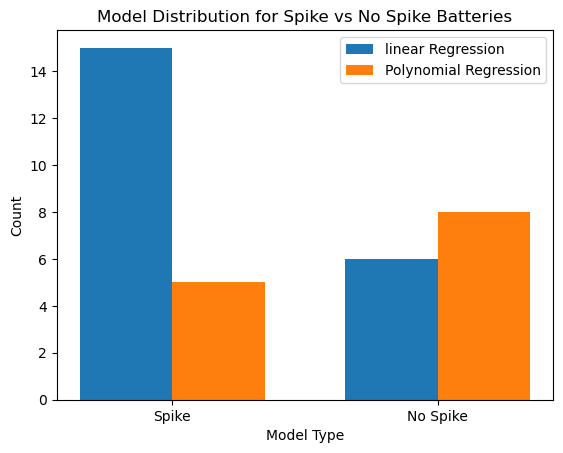

In [5]:
#Visualization of Model Distribution for Spike vs No Spike Batteries
import numpy as np
   
summary_df = pd.DataFrame({
    'Spike': Spike_Model_Distribution,
    'No Spike': No_Spike_Model_Distribution
}).fillna(0)

#Creating DF wrt to Spike and No Spike Models
summary_df=summary_df.transpose()
print("\nTransposed Summary DataFrame:")
print(summary_df)


x = np.arange(len(summary_df.index))
width = 0.35

plt.bar(x - width/2, summary_df['Linear Regression'], width, label='linear Regression')
plt.bar(x + width/2, summary_df['Polynomial Regression'], width, label='Polynomial Regression')

plt.xticks(x, summary_df.index)
plt.xlabel("Model Type")
plt.ylabel("Count")
plt.title("Model Distribution for Spike vs No Spike Batteries")
plt.legend()

plt.show()


## Model Selection Based on Degradation Behaviour

The relationship between degradation behaviour and model selection is summarized in the graph above.

For batteries that exhibited **spikes or regime changes**, linear regression was selected in most cases. Out of 20 spike batteries, **15 were modeled using linear regression**, while **5 used polynomial regression**. This suggests that the degradation trend before the spike generally follows a stable linear decline.

In contrast, batteries that **did not exhibit spikes** showed a different pattern. Among the 14 no-spike batteries, **8 were modeled using polynomial regression** and **6 used linear regression**. This indicates that when degradation progresses smoothly without abrupt regime changes, the SOH trajectory may exhibit slight curvature that polynomial regression can capture more effectively.

Overall, the results indicate that **linear regression is more suitable for degradation segments with regime changes**, while **polynomial regression becomes more useful when degradation follows a smoother, curved trend**.

In [6]:
#Average Error Analysis for Linear and Polynomial Models
Avg_linear_Error_Train = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Train_MAE'].mean()
Avg_polynomial_Error_Train = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Train_MAE'].mean()
Avg_linear_Error_Test = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Test_MAE'].mean()
Avg_polynomial_Error_Test = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Test_MAE'].mean()

Avg_Squared_Error_Train = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Train_MSE'].mean()
Avg_Squared_Error_Test = Regression_DF[Regression_DF['Model'] == 'Linear Regression']['Test_MSE'].mean()
Avg_Squared_Error_Polynomial_Train = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Train_MSE'].mean()
Avg_Squared_Error_Polynomial_Test = Regression_DF[Regression_DF['Model'] == 'Polynomial Regression']['Test_MSE'].mean()

overall_train_error = Regression_DF['Train_MAE'].mean()
overall_test_error = Regression_DF['Test_MAE'].mean()

Error_Results = {
    'Linear - Train': Avg_linear_Error_Train,
    'Polynomial - Train': Avg_polynomial_Error_Train,
    'Linear - Test': Avg_linear_Error_Test,
    'Polynomial - Test': Avg_polynomial_Error_Test,
    'Linear - Squared - Train': Avg_Squared_Error_Train,
    'Linear - Squared - Test': Avg_Squared_Error_Test,
    'Polynomial - Squared - Train': Avg_Squared_Error_Polynomial_Train,
    'Polynomial - Squared - Test': Avg_Squared_Error_Polynomial_Test,
    'Overall_Train_Error': overall_train_error,
    'Overall_Test_Error': overall_test_error
}

print("Average Error Results:")
for key, value in Error_Results.items():
    print(f"{key}: {value}")

Average Error Results:
Linear - Train: 2.1005952647884687
Polynomial - Train: 0.4480205461527022
Linear - Test: 4.714280000499585
Polynomial - Test: 8.880687132773025
Linear - Squared - Train: 25.2747298166829
Linear - Squared - Test: 148.3395930380373
Polynomial - Squared - Train: 0.45296852143925825
Polynomial - Squared - Test: 653.2582799899708
Overall_Train_Error: 1.7027532028946732
Overall_Test_Error: 5.7173039397505985


## Model Performance Comparison

The average error metrics provide insight into how well the regression models fit the degradation data and how well they generalize to unseen cycles.

Polynomial regression achieved significantly lower **training errors** compared to linear regression. The average training MAE for polynomial regression was **0.45**, while linear regression showed a higher training MAE of **2.10**. This indicates that polynomial regression can fit the training data more closely.

However, the **test errors reveal a different pattern**. The average test MAE for polynomial regression increased substantially to **8.88**, compared to **4.71** for linear regression. A similar trend is observed for the mean squared error, where polynomial regression produced a much larger test MSE (**653.26**) than linear regression (**148.34**).

This difference between training and test errors suggests that polynomial regression tends to **overfit the training data**, capturing noise and small fluctuations rather than the underlying degradation trend.

In contrast, linear regression demonstrates **more stable generalization performance**, making it a more reliable model for predicting long-term battery degradation behaviour.

Overall, the results indicate that while polynomial regression can achieve better training accuracy, **linear regression provides more consistent predictive performance across unseen battery cycles**.

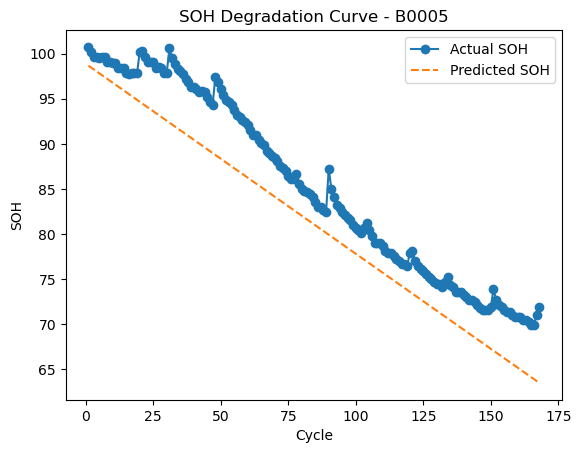

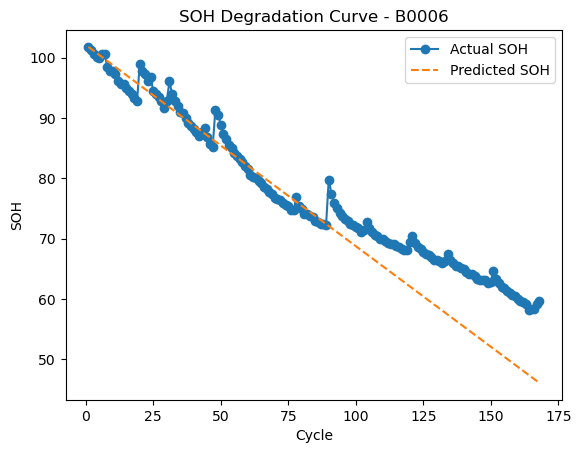

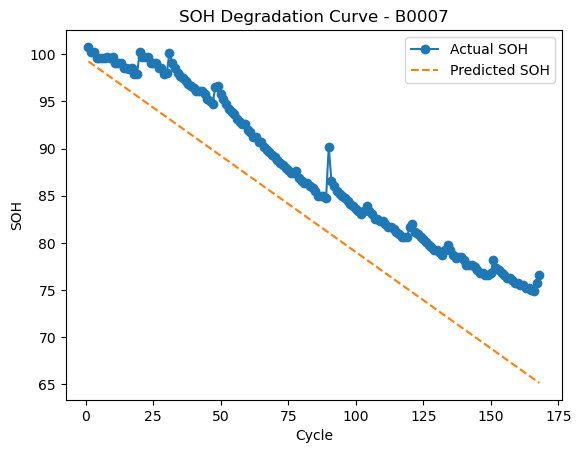

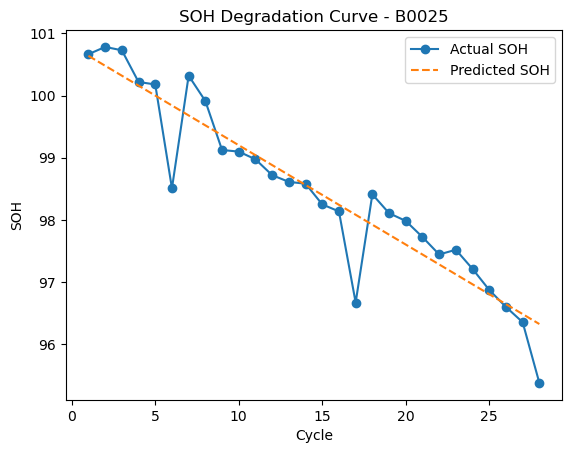

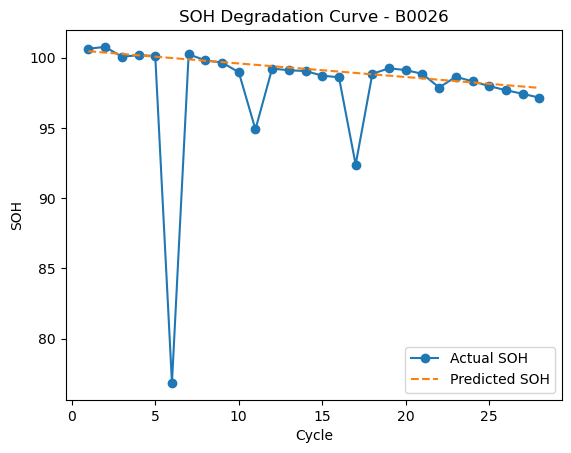

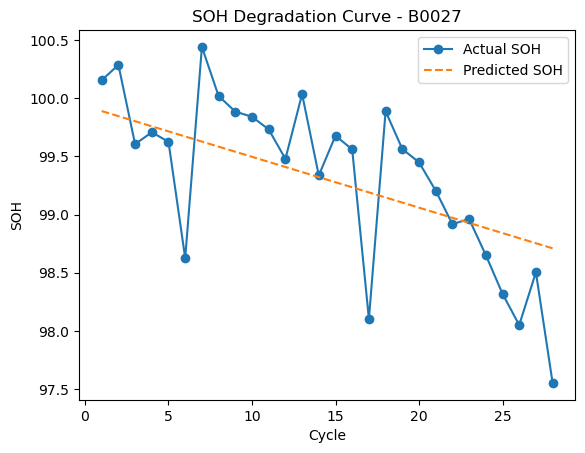

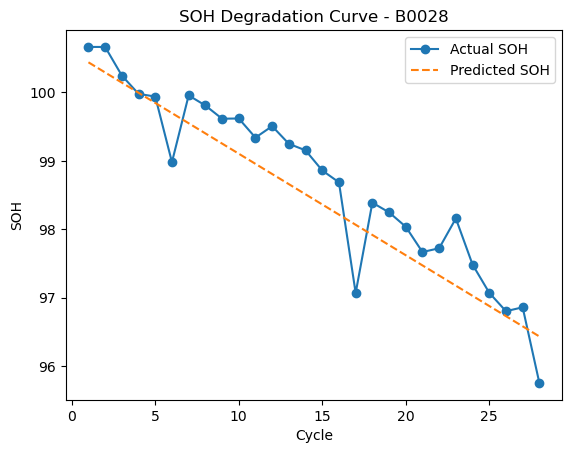

In [7]:
#Discharage Validation Analysis for Sample Batteries
# #Linear and Polynomia Counts 
Linear_Count = Regression_DF[Regression_DF['Model'] == 'Linear'].shape[0]
Polynomial_Count = Regression_DF[Regression_DF['Model'] == 'Polynomial'].shape[0]



#Visualization of degradation (Multiple Batteries)
Battery = ['B0005', 'B0006', 'B0007', 'B0025', 'B0026', 'B0027', 'B0028']
for battery in Battery:
    path = f"C:\\Projects\\Battery Engineering\\Summary Files\\Overall Summary\\{battery}_Overall_Summary.csv"
    Battery_DF = pd.read_csv(path)

    X = Battery_DF[['Cycle Pair']].values
    y_actual = Battery_DF['SOH'].values

    row = Regression_DF[Regression_DF['Battery'] == battery].iloc[0]

    slope = row['Slope']
    intercept = row['Intercept']

    y_pred = slope * X.flatten() + intercept

    plt.figure()

    plt.plot(X, y_actual, label="Actual SOH", marker='o', linestyle='-')
    plt.plot(X, y_pred, label="Predicted SOH", linestyle='--')

    plt.xlabel("Cycle")
    plt.ylabel("SOH")
    plt.title(f"SOH Degradation Curve - {battery}")

    plt.legend()
    plt.show()




## Model Fit: Actual vs Predicted SOH

The comparison between actual and predicted SOH values illustrates how well the regression model captures the degradation trend.

The predicted curve closely follows the overall downward trend of the measured SOH values, indicating that the regression model successfully captures the dominant degradation behaviour of the battery.

Small deviations between predicted and actual values are expected due to measurement noise and operational variability during cycling.

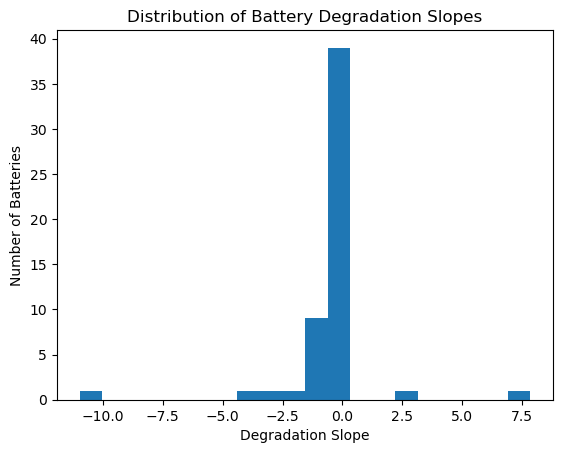

In [8]:
#Visualization of Degradation Slopes
plt.figure()

plt.hist(Regression_DF['Slope'], bins=20)
plt.xlabel("Degradation Slope")
plt.ylabel("Number of Batteries")
plt.title("Distribution of Battery Degradation Slopes")

plt.show()

## Degradation Rate Distribution

The degradation slope represents the rate at which battery health decreases with cycling.

Most slopes are negative, which confirms that battery capacity gradually decreases as the number of cycles increases. 
The distribution of slopes also shows variation across batteries, indicating that degradation rates differ depending on operating conditions and battery characteristics.

Batteries with steeper negative slopes experience faster degradation and are expected to reach the end-of-life threshold sooner.

In our results we can see majority of batteries have a degradation slope in the **range [-2.5 to 0]**

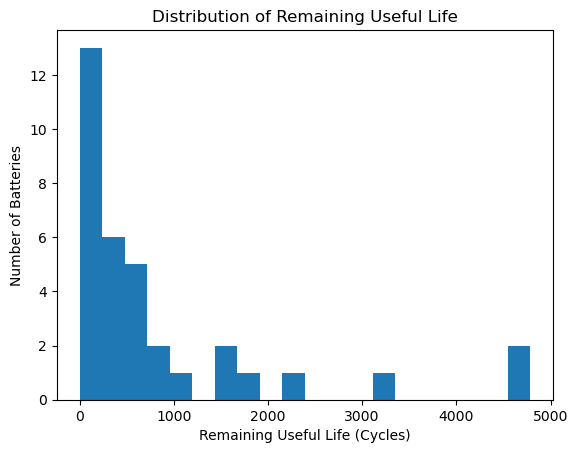

In [9]:
#Visualization of Remaining Useful Life (RUL) Distribution
plt.figure()
RUL = pd.to_numeric(EOL_DF['Remaining_Cycles'], errors='coerce')
RUL = RUL.dropna()

plt.hist(RUL, bins=20)

plt.xlabel("Remaining Useful Life (Cycles)")
plt.ylabel("Number of Batteries")
plt.title("Distribution of Remaining Useful Life")

plt.show()

## Remaining Useful Life Estimation

The Remaining Useful Life (RUL) was estimated by predicting the cycle at which the State of Health (SOH) reaches the 80% end-of-life threshold.

The distribution of RUL values highlights variability in battery lifetime across the dataset. 
Some batteries show longer predicted lifetimes due to slower degradation rates, while others exhibit faster capacity fade.


## Conclusion

This phase analyzed battery degradation behaviour using regression-based modeling techniques. Linear and polynomial regression models were applied to degradation segments, and model performance was evaluated using training and test error metrics.

The results indicate that **linear regression was selected for the majority of degradation segments**, suggesting that battery health generally follows a near-linear decline with increasing cycle count. Polynomial regression provided lower training error but exhibited significantly higher test error, indicating a tendency to overfit the training data.

The degradation slope distribution showed that most slopes were concentrated between **0 and −2.5**, indicating moderate and gradual capacity fade across the batteries. Using the selected regression models, the **Remaining Useful Life (RUL)** of each battery was estimated based on the cycle at which the SOH reaches the **80% end-of-life threshold**.

Overall, the analysis demonstrates that **simple regression models can effectively capture battery degradation trends and provide reasonable estimates of remaining battery life**.